# Phoneme Recognition Pipeline — APS Layer v2

**Author:**

Salvador Wahnon Palma s2665070@u.tsukuba.ac.jp

University of Tsukuba / Interaction Lab

<br>

**Objective:**

Given a learner's audio and a reference Japanese text, detect which phonemes were
actually produced and compare them against the expected phoneme sequence.
Returns `{ target_phoneme, produced_phoneme }` pairs compatible with `FeedbackGeneration.ipynb`.

---

## 1. Setup

In [ ]:
# System dependency — required by phonemizer
!apt-get install -q espeak-ng

# Python packages (torch is pre-installed in Colab)
!pip install -q phonemizer librosa soundfile
!pip install -q allosaurus
!pip install -q transformers torchaudio
!pip install -q openai-whisper
!pip install -q pykakasi
!pip install -q panphon

In [2]:
import os
import numpy as np
import librosa

try:
    from phonemizer import phonemize
    from phonemizer.separator import Separator
    print("Phonemizer Imported Successfully")
except (ImportError, OSError) as e:
    print(f"Phonemizer Error Importing: {e}")

try:
    from allosaurus.app import read_recognizer as allo_load
    print("Allosaurus Imported Successfully")
except (ImportError, OSError) as e:
    print(f"Allosaurus Error Importing: {e}")

try:
    from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
    import torch
    print("Wav2Vec2 Imported Successfully")
except (ImportError, OSError) as e:
    print(f"Wav2Vec2 Error Importing: {e}")

try:
    import whisper as whisper_lib
    print("Whisper Imported Successfully")
except (ImportError, OSError) as e:
    print(f"Whisper Error Importing: {e}")

Phonemizer Imported Successfully
Allosaurus Imported Successfully
Wav2Vec2 Imported Successfully
Whisper Imported Successfully


## 2. Grapheme to Phoneme

In [67]:
NormalizationTable = {
    "ɽ":  "ɾ",
    "ä":  "ɑ̟",  
    "ɯᵝ": "ɯ̟", 
    "ũ":  "m",
}


def NormalisePhonemes(phones):
    normalized = [NormalizationTable.get(p, p) for p in phones]
    result = []
    result.append(normalized[0])
    for i in range(1, len(normalized)):
        if normalized[i] == normalized[i - 1]:
            if normalized[i] in ["o̞", "e̞", "ɑ̟", "ɯ̟", "i"]:
                result.append("H")
                continue
            else:
                result.append("Q")
                continue
        
        if normalized[i].endswith("ː"):
            result.append(normalized[i][0])
            result.append("H")
        else:
            result.append(normalized[i])
            
            
    return result


def GetJapanesePhonemes(text, lang):
    raw = phonemize(
        text,
        backend="espeak",
        language=lang,
        with_stress=False,
        separator=Separator(phone=" ", word="    ", syllable="")
    )
    phones = [p for p in raw.strip().split(" ") if p]
    return NormalisePhonemes(phones)


TestingWords = [
    "がっこう", 
    "さくら", 
    "けんやかね",
    "さんばん",
    "さんぽ",   
    "さんねん", 
    "さんかい", 
    "あさ",
    "わかる",
    "かがく",
    "そら",
    "ろく",
    "さんびゃく",
    "さっぱり",
    "さんにん",
    "さんまえ",
    "めいし",
    "にゅうこく",
    "きいた",
]

print("\n=== Japanese ===")
for word in TestingWords:
    print(f"  {word}: {''.join(GetJapanesePhonemes(word, 'ja'))}")

print("\n=== English ===")
for word in ["Father", "Mother", "Kenya", "arena"]:
    print(f"  {word}: {''.join(GetJapanesePhonemes(word, 'en-us'))}")
  


=== Japanese ===
  がっこう: ɡɑ̟kQo̞ɯ̟
  さくら: sɑ̟kɯ̟ɾɑ̟
  けんやかね: ke̞mjɑ̟kɑ̟ne̞
  さんばん: sɑ̟mbɑ̟ɴ
  さんぽ: sɑ̟mpo̞
  さんねん: sɑ̟nQe̞ɴ
  さんかい: sɑ̟ŋkɑ̟i
  あさ: ɑ̟sɑ̟
  わかる: wɑ̟kɑ̟ɾɯ̟
  かがく: kɑ̟ɡɑ̟kɯ̟
  そら: so̞ɾɑ̟
  ろく: ɾo̞kɯ̟
  さんびゃく: sɑ̟mbʲɑ̟kɯ̟
  さっぱり: sɑ̟pQɑ̟ɾi
  さんにん: sɑ̟nQiɴ
  さんまえ: sɑ̟mQɑ̟e̞
  めいし: me̞iɕi
  にゅうこく: nʲɯ̟Hko̞kɯ̟
  きいた: kiHtɑ̟

=== English ===
  Father: fɑHðɚ
  Mother: mʌðɚ
  Kenya: kɛnjə
  arena: ɚɹiHnə


## 3. Phoneme Detection
### 3.1 Allosaurus

In [4]:
allo_model = allo_load()
print("Allosaurus model loaded.")

downloading model  latest
from:  https://github.com/xinjli/allosaurus/releases/download/v1.0/latest.tar.gz
to:    /usr/local/lib/python3.12/dist-packages/allosaurus/pretrained
please wait...
Allosaurus model loaded.


In [5]:
ALLOSAURUS_VOWEL_NORM = {
    "a":  "ɑ̟",   # broad /a/  → Vance near-open central  [ɑ̟]
    "u":  "ɯ̟",   # broad /u/  → Vance compressed back    [ɯ̟]
    "o":  "o̞",   # broad /o/  → Vance lowered mid-back   [o̞]
    "e":  "e̞",   # broad /e/  → Vance lowered mid-front  [e̞]
    # /i/ is identical in both conventions
}


def NormalizeAllosaurus(phones):
    result = []
    for phone in phones:
        if phone.endswith("ː") and len(phone) > 1:
            base = phone[:-1]
            normBase = ALLOSAURUS_VOWEL_NORM.get(base, base)
            result.append(normBase)
            if normBase in ["o̞", "e̞", "ɑ̟", "ɯ̟", "i"]:
                result.append("H")
            else:
                result.append("Q")  
        else:
            result.append(ALLOSAURUS_VOWEL_NORM.get(phone, phone))
    return result


def RecognizeAllosaurus(path, lang="jpn"):
    raw = allo_model.recognize(path, lang)
    phones = [p for p in raw.strip().split(" ") if p]
    return NormalizeAllosaurus(phones)

### 3.2 Wav2Vec2

In [6]:
W2V_MODEL_ID = "facebook/wav2vec2-lv-60-espeak-cv-ft"

print(f"Loading {W2V_MODEL_ID} ...")
w2v_processor = Wav2Vec2Processor.from_pretrained(W2V_MODEL_ID)
w2v_model = Wav2Vec2ForCTC.from_pretrained(W2V_MODEL_ID)
w2v_model.eval()
print("Wav2Vec2 model loaded.")


Loading facebook/wav2vec2-lv-60-espeak-cv-ft ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.86k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/4.64k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

Wav2Vec2 model loaded.


model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

In [7]:

ESPEAK_TO_IPA = {
    "ɹ":  "r",
    "t͡ɕ": "tɕ",
    "d͡ʑ": "dʑ",
}


def NormalizeESpeak(phone):
    return ESPEAK_TO_IPA.get(phone, phone)


def RecognizeWav2Vec(path):
    audio, _ = librosa.load(path, sr=16000, mono=True)

    inputs = w2v_processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        logits = w2v_model(**inputs).logits

    predictedIDs  = torch.argmax(logits, dim=-1)
    raw = w2v_processor.batch_decode(predictedIDs)[0]

    phones = [NormalizeESpeak(p) for p in raw.strip().split(" ") if p]
    return phones

### 3.3 Whisper + Grapheme to Phoneme

In [8]:
import whisper as whisper_lib

whisper_model = whisper_lib.load_model("large-v3")
print("Whisper large-v3 loaded.")

100%|██████████████████████████████████████| 2.88G/2.88G [00:28<00:00, 109MiB/s]


Whisper large-v3 loaded.


In [9]:
import pykakasi

def toHiragana(text):
    kks = pykakasi.kakasi()
    result = kks.convert(text)
    return "".join([item['hira'] for item in result])


def RecognizeWhisper(path):
    
    result = whisper_model.transcribe(path, language="ja")
    transcription = result["text"]
    hiragana = toHiragana(transcription)
    return GetJapanesePhonemes(hiragana, "ja")

### 3.4 Wav2Vec2 XLSR-53 Phoneme

**Model:** `facebook/wav2vec2-xlsr-53-espeak-cv-ft`

Canonical implementation of the **Wav2Vec2Phoneme** architecture (Xu et al., 2021) for zero-shot cross-lingual phoneme recognition. Key differences from Option B:

- Trained with a **cross-lingual articulatory feature mapping** objective — phonemes across all 53 training languages share a common articulatory space, enabling generalisation to unseen phones.
- Decoded with `Wav2Vec2PhonemeCTCTokenizer` (explicit IPA phoneme vocabulary) instead of the generic processor.

Because /r/ (English retroflex) and /ɾ/ (Japanese flap) have distinct articulatory features, the model encodes them as separate tokens — the property needed for L1 substitution detection.

**Memory note:** ~1.26 GB. If Whisper large-v3 is also loaded, consider switching to `whisper-medium` to avoid OOM.

**First run:** downloads model weights. Cached afterwards.

In [10]:
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2PhonemeCTCTokenizer

XLSR_MODEL_ID = "facebook/wav2vec2-xlsr-53-espeak-cv-ft"

print(f"Loading {XLSR_MODEL_ID} ...")
xlsr_extractor = Wav2Vec2FeatureExtractor.from_pretrained(XLSR_MODEL_ID)
xlsr_tokenizer = Wav2Vec2PhonemeCTCTokenizer.from_pretrained(XLSR_MODEL_ID)
xlsr_model     = Wav2Vec2ForCTC.from_pretrained(XLSR_MODEL_ID)
xlsr_model.eval()
print("XLSR-53 Phoneme model loaded.")

Loading facebook/wav2vec2-xlsr-53-espeak-cv-ft ...


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/412 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/4.64k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.86k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

XLSR-53 Phoneme model loaded.


model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

In [11]:
def RecognizeXLSR(path):
    audio, _ = librosa.load(path, sr=16000, mono=True)

    inputs = xlsr_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        logits = xlsr_model(**inputs).logits

    predicted_ids = torch.argmax(logits, dim=-1)
    raw           = xlsr_tokenizer.batch_decode(predicted_ids)[0]

    # Same espeak IPA output as lv-60 — reuse the same normalization
    phones = [NormalizeESpeak(p) for p in raw.strip().split(" ") if p]
    return phones

## 4. Sequence Alignment

Aligns the produced phoneme sequence against the expected sequence using
edit distance (Levenshtein) with backtracking.

Returns pairs `(expected, produced)` for every position:
- `("ɾ", "r")` — substitution (learner said English /r/ instead of Japanese /ɾ/)
- `("Q", None)` — deletion (geminate closure was dropped)
- `(None, "l")` — insertion (extra phone produced)
- `("a", "a")` — correct

In [12]:
import unicodedata


def _display_width(s):
    """Visual width of a string, excluding Unicode combining diacritics."""
    if s is None:
        return 1
    return sum(1 for c in s if not unicodedata.combining(c))


def _visualize_matrix(dp, expected, produced, path_coords):
    """Heatmap of the Levenshtein DP matrix with the alignment path overlaid."""
    import matplotlib.pyplot as plt
    import numpy as np

    m, n = len(expected), len(produced)
    arr  = np.array(dp, dtype=float)

    cell = 0.55
    fig, ax = plt.subplots(figsize=((n + 1) * cell + 1.5, (m + 1) * cell + 1.5))

    im = ax.imshow(arr, cmap="Blues", aspect="auto", vmin=0)
    plt.colorbar(im, ax=ax, shrink=0.8, label="edit distance")

    # Cell values — white text on dark cells for readability
    thresh = arr.max() * 0.6
    for i in range(m + 1):
        for j in range(n + 1):
            color = "white" if arr[i, j] > thresh else "black"
            ax.text(j, i, dp[i][j], ha="center", va="center", fontsize=8, color=color)

    # Alignment path
    ys = [c[0] for c in path_coords]
    xs = [c[1] for c in path_coords]
    ax.plot(xs, ys, color="red", linewidth=2.5, zorder=3)
    ax.scatter(xs, ys, color="red", s=25, zorder=4)

    ax.set_xticks(range(n + 1))
    ax.set_xticklabels(["∅"] + list(produced), fontsize=8, rotation=45, ha="right")
    ax.set_yticks(range(m + 1))
    ax.set_yticklabels(["∅"] + list(expected), fontsize=8)
    ax.set_xlabel("Produced →", labelpad=8)
    ax.set_ylabel("← Expected", labelpad=8)
    ax.set_title(f"Levenshtein DP Matrix  (edit distance = {dp[m][n]})")
    plt.tight_layout()
    plt.show()


def AlignSequence(expected, produced, visualize=False):
    m, n = len(expected), len(produced)

    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if expected[i - 1] == produced[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j]     + 1,
                dp[i][j - 1]     + 1,
                dp[i - 1][j - 1] + cost
            )

    path, path_coords = [], []
    i, j = m, n
    while i > 0 or j > 0:
        path_coords.append((i, j))
        if i > 0 and j > 0:
            cost = 0 if expected[i - 1] == produced[j - 1] else 1
            if dp[i][j] == dp[i - 1][j - 1] + cost:
                path.append((expected[i - 1], produced[j - 1]))
                i -= 1; j -= 1
                continue
        if i > 0 and (j == 0 or dp[i][j] == dp[i - 1][j] + 1):
            path.append((expected[i - 1], None))
            i -= 1
        else:
            path.append((None, produced[j - 1]))
            j -= 1
    path_coords.append((0, 0))

    path = list(reversed(path))
    path_coords = list(reversed(path_coords))

    if visualize:
        _visualize_matrix(dp, expected, produced, path_coords)

    return path


def ExtractErrors(alignment, reference_text=""):
    errors = []
    for position, (expected, produced) in enumerate(alignment):
        if expected == produced:
            continue
        error_type = (
            "substitution" if expected and produced else
            "deletion"     if expected else
            "insertion"
        )
        errors.append({
            "target_phoneme":   f"/{expected}/" if expected else None,
            "produced_phoneme": f"/{produced}/" if produced else None,
            "position":         position,
            "error_type":       error_type,
            "word":             reference_text,
        })
    return errors

In [13]:
def PrintAlignment(alignment, label="", chunk=15):
    """
    Column-aligned diff view of a phoneme alignment.

    Ref: s   ɑ̟   i   k   i   ɴ   ...
    Out: s   e̞   –   k   i   n   ...
         ✓   ✗   D   ✓   ✓   ✗   ...

    alignment — list of (expected, produced) tuples from AlignSequence
    label     — optional header label (e.g. recognizer name)
    chunk     — tokens per row before wrapping (default 15)

    Status symbols:
      ✓  match
      ✗  substitution
      D  deletion  (expected phone absent in produced)
      I  insertion (extra phone produced)
    """
    def dw(s):
        if s is None: return 1
        return sum(1 for c in s if not unicodedata.combining(c))

    exp_toks  = [e if e is not None else "–" for e, p in alignment]
    prod_toks = [p if p is not None else "–" for e, p in alignment]
    statuses  = []
    for e, p in alignment:
        if   e == p:      statuses.append("✓")
        elif e is None:   statuses.append("I")
        elif p is None:   statuses.append("D")
        else:             statuses.append("✗")

    # Per-column width = max display width of ref/out tokens + 1 space padding
    col_w = [max(dw(exp_toks[i]), dw(prod_toks[i]), 1) + 1 for i in range(len(alignment))]

    def fmt(tokens, widths):
        return "".join(t + " " * (w - dw(t)) for t, w in zip(tokens, widths))

    if label:
        bar = "─" * max(0, 54 - len(label))
        print(f"\n── {label} {bar}")

    for start in range(0, len(alignment), chunk):
        end = min(start + chunk, len(alignment))
        ws  = col_w[start:end]
        print("Ref: " + fmt(exp_toks[start:end],  ws))
        print("Out: " + fmt(prod_toks[start:end], ws))
        print("     " + fmt(statuses[start:end],  ws))
        if end < len(alignment):
            print()

    n_ok  = sum(1 for e, p in alignment if e == p)
    n_err = len(alignment) - n_ok
    print(f"\n     {n_ok}/{len(alignment)} correct  |  {n_err} error(s)")

## 5. Pipeline Runner

In [27]:
#i and u are devoiced when surrounded by voiceless consonants.

def CorrectDevoicing(phones):
    corrected = []
    voiceless_consonants = ["p", "t", "k", "s", "ɕ", "ç", "h", "ɸ"]

    for i, p in enumerate(phones):
        if p in ["i", "u", "ɯ̟"]:
            prev_voiceless = (i == 0 or phones[i - 1] in voiceless_consonants)
            next_voiceless = (i == len(phones) - 1 or phones[i + 1] in voiceless_consonants)
            if prev_voiceless and next_voiceless:
                continue
        corrected.append(p)
    return corrected


test = "k o̞ m j ɑ̟ h ɑ̟ i ɕ Q o̞ ɯ̟ n i s ɯ̟ ɡ o̞ s e̞ t e̞ t ɑ̟ n o̞ ɕ i k ɑ̟ t Q ɑ̟ d e̞ s ɯ̟ "
print("Before devoicing correction:")
print(" ".join(test.split()))
corrected = CorrectDevoicing(test.split())
print("\nAfter devoicing correction:")
print(" ".join(corrected))


Before devoicing correction:
k o̞ m j ɑ̟ h ɑ̟ i ɕ Q o̞ ɯ̟ n i s ɯ̟ ɡ o̞ s e̞ t e̞ t ɑ̟ n o̞ ɕ i k ɑ̟ t Q ɑ̟ d e̞ s ɯ̟

After devoicing correction:
k o̞ m j ɑ̟ h ɑ̟ i ɕ Q o̞ ɯ̟ n i s ɯ̟ ɡ o̞ s e̞ t e̞ t ɑ̟ n o̞ ɕ k ɑ̟ t Q ɑ̟ d e̞ s


In [28]:
def RunPipeline(path, reference, recognizer="whisper", language="ja"):

    expected = GetJapanesePhonemes(reference, lang=language)
    expected = CorrectDevoicing(expected)

    if recognizer == "whisper":
        produced = RecognizeWhisper(path)
    elif recognizer == "allosaurus":
        produced = RecognizeAllosaurus(path)
    elif recognizer == "wav2vec":
        produced = RecognizeWav2Vec(path)
    elif recognizer == "xlsr":
        produced = RecognizeXLSR(path)
    else:
        raise ValueError(f"Unknown recognizer '{recognizer}'. Choose 'whisper', 'allosaurus', 'wav2vec', or 'xlsr'.")

    alignment = AlignSequence(expected, produced)
    errors    = ExtractErrors(alignment, reference_text=reference)

    return {
        "expected":  expected,
        "produced":  produced,
        "alignment": alignment,
        "errors":    errors,
    }

## 6. Audio Setup

In [58]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

MP3_DIR = "/content/drive/MyDrive/Tsukuba/"
WAV_DIR = "/content/drive/MyDrive/Tsukuba/"

os.makedirs(WAV_DIR, exist_ok=True)
print(f"MP3 source : {MP3_DIR}")
print(f"WAV output : {WAV_DIR}")
print(f"MP3 files found: {[f for f in os.listdir(MP3_DIR) if f.endswith('.mp3')] if os.path.isdir(MP3_DIR) else 'folder not found'}")

Mounted at /content/drive
MP3 source : /content/drive/MyDrive/Tsukuba/
WAV output : /content/drive/MyDrive/Tsukuba/
MP3 files found: ['JapanesePronunciationTest_1.mp3', 'Pron1.mp3', 'Pron2.mp3', 'Correct-converted.mp3', 'Wrong-converted.mp3', 'LongSentence1.mp3', 'LongSentence2.mp3', 'LongSent1.mp3', 'LongSent2.mp3']


In [59]:
import soundfile as sf


def ConvertToWav(path, outDir=WAV_DIR):
    os.makedirs(outDir, exist_ok=True)
    stem = os.path.splitext(os.path.basename(path))[0]
    
    wavPath = os.path.join(outDir, stem + ".wav")
    audio, _ = librosa.load(path, sr=16000, mono=True)
    
    sf.write(wavPath, audio, 16000, subtype="PCM_16")
    return wavPath


mp3s = [f for f in os.listdir(MP3_DIR) if f.endswith(".mp3")] if os.path.isdir(MP3_DIR) else []

print(f"Converting {len(mp3s)} file(s)...")
for mp3 in mp3s:
    src = os.path.join(MP3_DIR, mp3)
    dst = ConvertToWav(src)
    
    print(f"  {mp3}  →  {os.path.basename(dst)}")
print(f"\nAll WAVs saved to: {WAV_DIR}")

AUDIO_DIR = WAV_DIR

Converting 9 file(s)...
  JapanesePronunciationTest_1.mp3  →  JapanesePronunciationTest_1.wav
  Pron1.mp3  →  Pron1.wav
  Pron2.mp3  →  Pron2.wav
  Correct-converted.mp3  →  Correct-converted.wav
  Wrong-converted.mp3  →  Wrong-converted.wav
  LongSentence1.mp3  →  LongSentence1.wav
  LongSentence2.mp3  →  LongSentence2.wav
  LongSent1.mp3  →  LongSent1.wav
  LongSent2.mp3  →  LongSent2.wav

All WAVs saved to: /content/drive/MyDrive/Tsukuba/


## 7. Test APS's

In [75]:
TEST_CASES = [
    # {"audio": f"{AUDIO_DIR}/Correct-converted.wav", "reference": "さいきん さっぽろ は ぶっか が たかい"},
    # {"audio": f"{AUDIO_DIR}/Pron2.wav", "reference": "おはようございます"},
    {"audio": f"{AUDIO_DIR}/Wrong-converted.wav",   "reference": "さいきん さっぽろ は ぶっか が たかい"},
    # {"audio": f"{AUDIO_DIR}/LongSentence1.wav", "reference": "こんやはいっしょにすごせてたのしかったです"},
    # {"audio": f"{AUDIO_DIR}/LongSent1.wav", "reference": "きいた こと が ありますか"},
    # {"audio": f"{AUDIO_DIR}/Pron1.wav", "reference": "おはようございます"},
]

Recognizers = ["allosaurus", "wav2vec", "xlsr", "whisper"]

for case in TEST_CASES:
    path      = case["audio"]
    reference = case["reference"]
    

    if not os.path.isfile(path):
        print(f"[SKIP] {path} not found\n")
        continue

    filename = path[path.rfind("/") + 1 : -4]
    print(f"\n{'═' * 58}")
    print(f"  File      : {filename}")
    print(f"  Reference : {reference}")
    print(f"{'═' * 58}")

    results = {r: RunPipeline(path, reference, recognizer=r) for r in Recognizers}

    for rec, result in results.items():
        PrintAlignment(result["alignment"], label=rec)

    print()


══════════════════════════════════════════════════════════
  File      : Wrong-converted
  Reference : さいきん さっぽろ は ぶっか が たかい
══════════════════════════════════════════════════════════



── allosaurus ────────────────────────────────────────────
Ref: s ɑ̟ i k – i ɴ s ɑ̟ p Q o̞ ɾ o̞ h 
Out: s e̞ i k Q i n s ɑ̟ p – o̞ ɾ o̞ – 
     ✓ ✗ ✓ ✓ I ✓ ✗ ✓ ✓ ✓ D ✓ ✓ ✓ D 

Ref: ɑ̟ b ɯ̟ k Q ɑ̟ ɡ ɑ̟ t ɑ̟ k ɑ̟ i 
Out: ɑ̟ b o̞ k – e̞ p e̞ p e̞ k ɾ e̞ 
     ✓ ✓ ✗ ✓ D ✗ ✗ ✗ ✗ ✗ ✓ ✗ ✗ 

     14/28 correct  |  14 error(s)

── wav2vec ───────────────────────────────────────────────
Ref: s ɑ̟ i k i ɴ s ɑ̟ p Q o̞ ɾ o̞ h  ɑ̟ 
Out: s – a k i n s a p – – o r oː a 
     ✓ D ✗ ✓ ✓ ✗ ✓ ✗ ✓ D D ✗ ✗ ✗  ✗ 

Ref: b ɯ̟ k Q ɑ̟ ɡ ɑ̟ t ɑ̟ k ɑ̟ i 
Out: b u k – a ɡ a t a k – a 
     ✓ ✗ ✓ D ✗ ✓ ✗ ✓ ✗ ✓ D ✗ 

     10/27 correct  |  17 error(s)

── xlsr ──────────────────────────────────────────────────
Ref: s ɑ̟ i  k i ɴ s ɑ̟ p Q o̞ ɾ o̞ h ɑ̟ 
Out: s – aɪ k i n s a p – – – o r a 
     ✓ D ✗  ✓ ✓ ✗ ✓ ✗ ✓ D D D ✗ ✗ ✗ 

Ref: b ɯ̟ k Q ɑ̟ ɡ ɑ̟ t ɑ̟ k ɑ̟ i  
Out: b u k – a ɡ a t a k – aɪ 
     ✓ ✗ ✓ D ✗ ✓ ✗ ✓ ✗ ✓ D ✗  

     10/27 correct  |  17 error(s)

── whisper ───────────────────────────────────────────────


## 8. Phoneme Vector Space

In [38]:
inventory = ['I', 'a', 'aː', 'ã', 'ă', 'b', 'bʲ', 'bʲj', 'bʷ', 'bʼ', 'bː', 'b̞', 'b̤', 'b̥', 'c', 'd', 'dʒ', 'dʲ', 'dː', 'd̚', 'd̥', 'd̪', 'd̯', 'd͡z', 'd͡ʑ', 'd͡ʒ', 'd͡ʒː', 'd͡ʒ̤', 'e', 'eː', 'e̞', 'f', 'fʲ', 'fʷ', 'fː', 'g', 'gʲ', 'gʲj', 'gʷ', 'gː', 'h', 'hʷ', 'i', 'ij', 'iː', 'i̞', 'i̥', 'i̯', 'j', 'k', 'kx', 'kʰ', 'kʲ', 'kʲj', 'kʷ', 'kʷʼ', 'kʼ', 'kː', 'k̟ʲ', 'k̟̚', 'k͡p̚', 'l', 'lʲ', 'lː', 'l̪', 'm', 'mʲ', 'mʲj', 'mʷ', 'mː', 'n', 'nj', 'nʲ', 'nː', 'n̪', 'n̺', 'o', 'oː', 'o̞', 'o̥', 'p', 'pf', 'pʰ', 'pʲ', 'pʲj', 'pʷ', 'pʷʼ', 'pʼ', 'pː', 'p̚', 'q', 'r', 'rː', 's', 'sʲ', 'sʼ', 'sː', 's̪', 't', 'ts', 'tsʰ', 'tɕ', 'tɕʰ', 'tʂ', 'tʂʰ', 'tʃ', 'tʰ', 'tʲ', 'tʷʼ', 'tʼ', 'tː', 't̚', 't̪', 't̪ʰ', 't̪̚', 't͡s', 't͡sʼ', 't͡ɕ', 't͡ɬ', 't͡ʃ', 't͡ʃʲ', 't͡ʃʼ', 't͡ʃː', 'u', 'uə', 'uː', 'u͡w', 'v', 'vʲ', 'vʷ', 'vː', 'v̞', 'v̞ʲ', 'w', 'x', 'x̟ʲ', 'y', 'z', 'zj', 'zʲ', 'z̪', 'ä', 'æ', 'ç', 'çj', 'ð', 'ø', 'ŋ', 'ŋ̟', 'ŋ͡m', 'œ', 'œ̃', 'ɐ', 'ɐ̞', 'ɑ', 'ɑ̱', 'ɒ', 'ɓ', 'ɔ', 'ɔ̃', 'ɕ', 'ɕː', 'ɖ̤', 'ɗ', 'ə', 'ɛ', 'ɛ̃', 'ɟ', 'ɡ', 'ɡʲ', 'ɡ̤', 'ɡ̥', 'ɣ', 'ɣj', 'ɤ', 'ɤɐ̞', 'ɤ̆', 'ɥ', 'ɦ', 'ɨ', 'ɪ', 'ɫ', 'ɯ', 'ɯ̟', 'ɯ̥', 'ɰ', 'ɱ', 'ɲ', 'ɳ', 'ɴ', 'ɵ', 'ɸ', 'ɹ', 'ɹ̩', 'ɻ', 'ɻ̩', 'ɽ', 'ɾ', 'ɾj', 'ɾʲ', 'ɾ̠', 'ʀ', 'ʁ', 'ʁ̝', 'ʂ', 'ʃ', 'ʃʲː', 'ʃ͡ɣ', 'ʈ', 'ʉ̞', 'ʊ', 'ʋ', 'ʋʲ', 'ʌ', 'ʎ', 'ʏ', 'ʐ', 'ʑ', 'ʒ', 'ʒ͡ɣ', 'ʔ', 'ʝ', 'ː', 'β', 'β̞', 'θ', 'χ', 'ә', 'ḁ']

Mapped  : 227 phones

Still skipped after normalization (1):
  'ә'           [U+04D9]


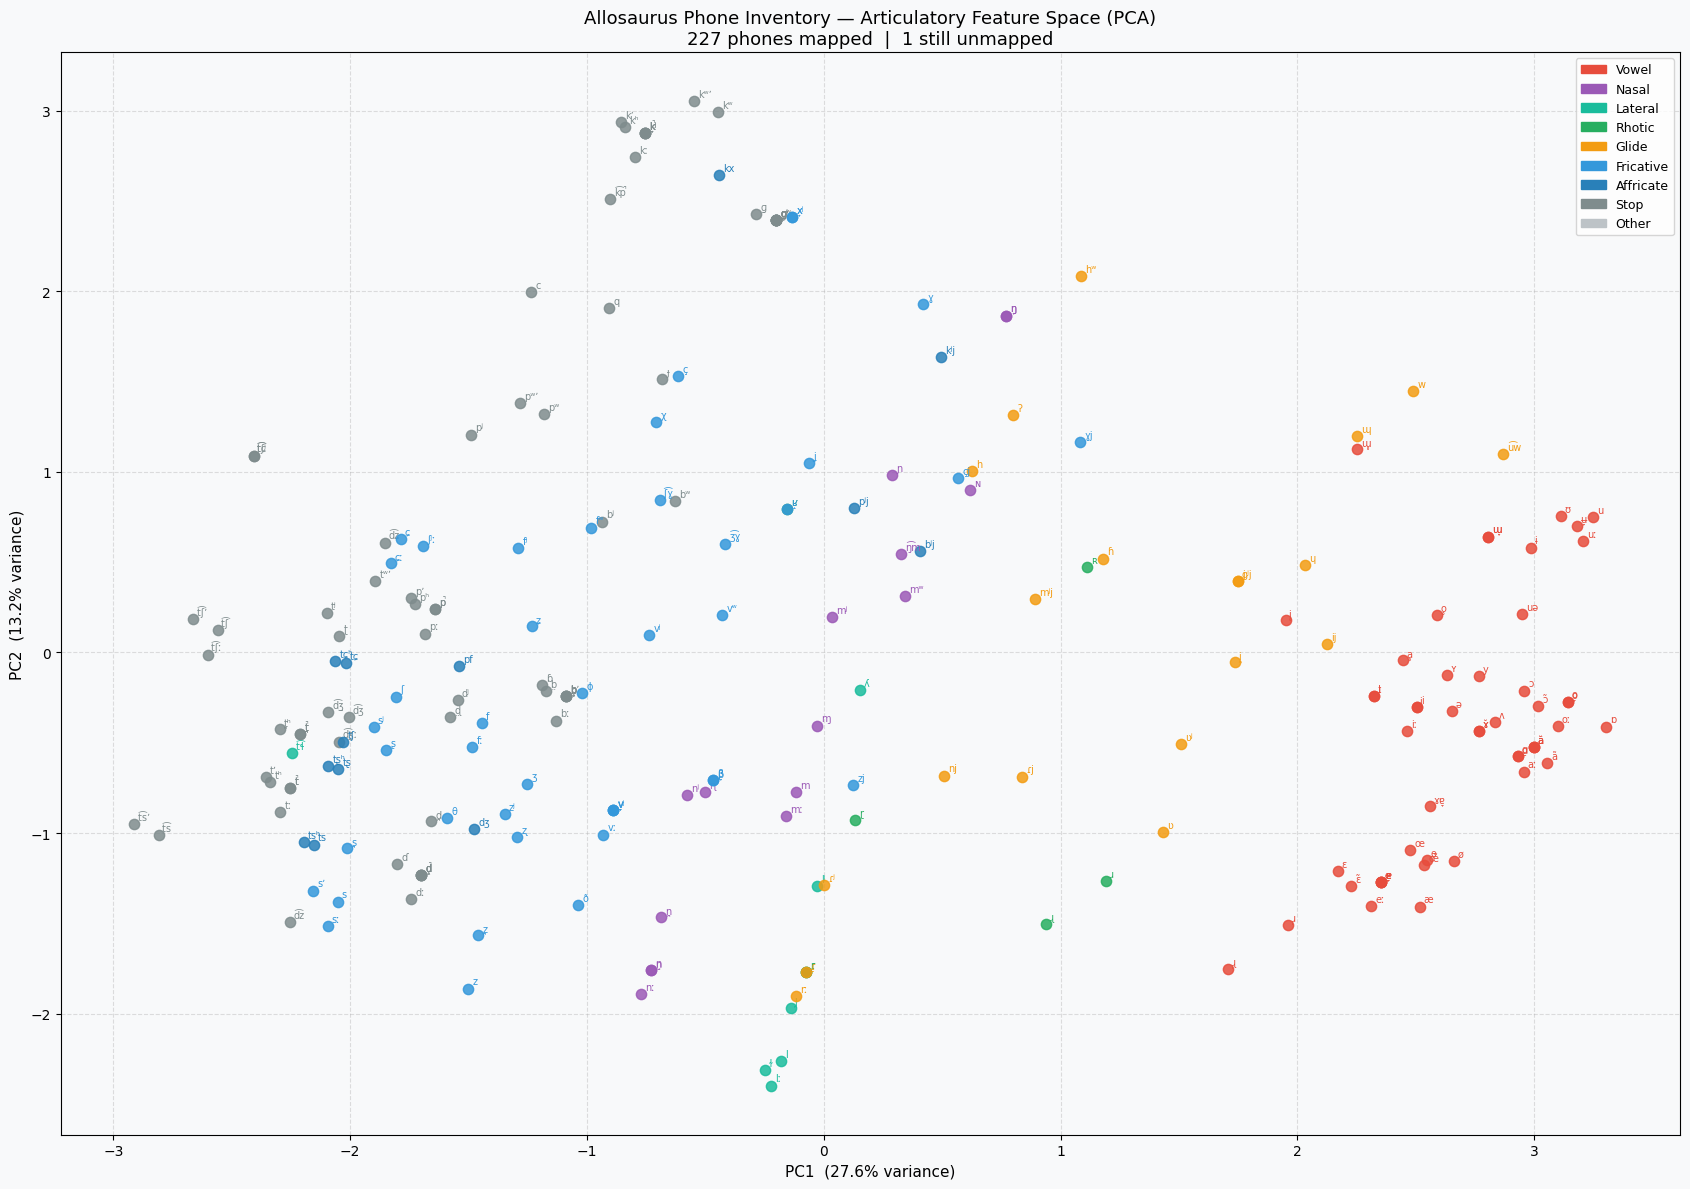

Saved: allosaurus_phoneme_space.png


In [ ]:
import panphon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

ft = panphon.FeatureTable()


ALLO_SYMBOL_MAP = {
    "g":  "ɡ",  
    "I":  "ɪ", 
    "ä":  "a", 
    "ǝ":  "ə",  
    "ả":  "ə",  
    "ε":  "e", 
}

_STRIP = str.maketrans("", "", "ʲʷʰʼˤːˑ")

def _resolve_phone(phone):
   
    normalized = ALLO_SYMBOL_MAP.get(phone, phone)

    vecs = ft.word_to_vector_list(normalized, numeric=True)
    if vecs:
        return normalized, vecs

    base = normalized.translate(_STRIP)
    if base and base != normalized:
        base = ALLO_SYMBOL_MAP.get(base, base)
        vecs = ft.word_to_vector_list(base, numeric=True)
        if vecs:
            return base, vecs

    return phone, None

vectors      = []
plot_labels  = []  
orig_labels  = []  
skipped      = []

for phone in inventory:
    if phone in {"ː", "ˑ", "·"}:
        continue

    display, vecs = _resolve_phone(phone)
    if vecs is None:
        skipped.append(phone)
        continue


    avg = [sum(col) / len(col) for col in zip(*vecs)]
    vectors.append(avg)
    plot_labels.append(phone)  
    orig_labels.append(phone)

print(f"Mapped  : {len(vectors)} phones")
if skipped:
    print(f"\nStill skipped after normalization ({len(skipped)}):")
    for p in skipped:
        codes = " ".join(f"U+{ord(c):04X}" for c in p)
        print(f"  {repr(p):<12}  [{codes}]")


X      = np.array(vectors)
pca    = PCA(n_components=2)
coords = pca.fit_transform(X)
var    = pca.explained_variance_ratio_

FEATURE_NAMES = ft.names

def get_feat(vec, name):
    return vec[FEATURE_NAMES.index(name)]

CLASS_COLOURS = {
    "vowel":     "#e74c3c",
    "nasal":     "#9b59b6",
    "lateral":   "#1abc9c",
    "rhotic":    "#27ae60",
    "glide":     "#f39c12",
    "fricative": "#3498db",
    "affricate": "#2980b9",
    "stop":      "#7f8c8d",
    "other":     "#bdc3c7",
}

_RHOTICS = {"r", "ɾ", "ɻ", "ɽ", "ʀ", "ʁ", "ɹ", "ɹ̩", "ɻ̩"}

def classify(phone, vec):
    syl  = get_feat(vec, "syl")
    son  = get_feat(vec, "son")
    nas  = get_feat(vec, "nas")
    lat  = get_feat(vec, "lat")
    cont = get_feat(vec, "cont")
    if syl ==  1:                   return "vowel"
    if nas ==  1:                   return "nasal"
    if lat ==  1:                   return "lateral"
    if phone in _RHOTICS:           return "rhotic"
    if son ==  1:                   return "glide"
    if cont == 1:                   return "fricative"
    if len(ft.word_to_vector_list(phone, numeric=True)) > 1: return "affricate"
    if cont == -1:                  return "stop"
    return "other"

classes = [classify(plot_labels[i], vectors[i]) for i in range(len(plot_labels))]

fig, ax = plt.subplots(figsize=(17, 12))
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

for i, (x, y) in enumerate(coords):
    colour = CLASS_COLOURS.get(classes[i], CLASS_COLOURS["other"])
    ax.scatter(x, y, color=colour, s=55, zorder=3, alpha=0.85)
    ax.annotate(
        plot_labels[i],
        (x, y),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points",
        color=colour,
        fontfamily="DejaVu Sans",
    )

ax.set_xlabel(f"PC1  ({var[0]*100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({var[1]*100:.1f}% variance)", fontsize=11)
ax.set_title(
    f"Allosaurus Phone Inventory — Articulatory Feature Space (PCA)\n"
    f"{len(vectors)} phones mapped  |  {len(skipped)} still unmapped",
    fontsize=13,
)
ax.grid(True, linestyle="--", alpha=0.4)

legend_patches = [
    mpatches.Patch(color=c, label=cls.capitalize())
    for cls, c in CLASS_COLOURS.items()
]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig("allosaurus_phoneme_space.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: allosaurus_phoneme_space.png")

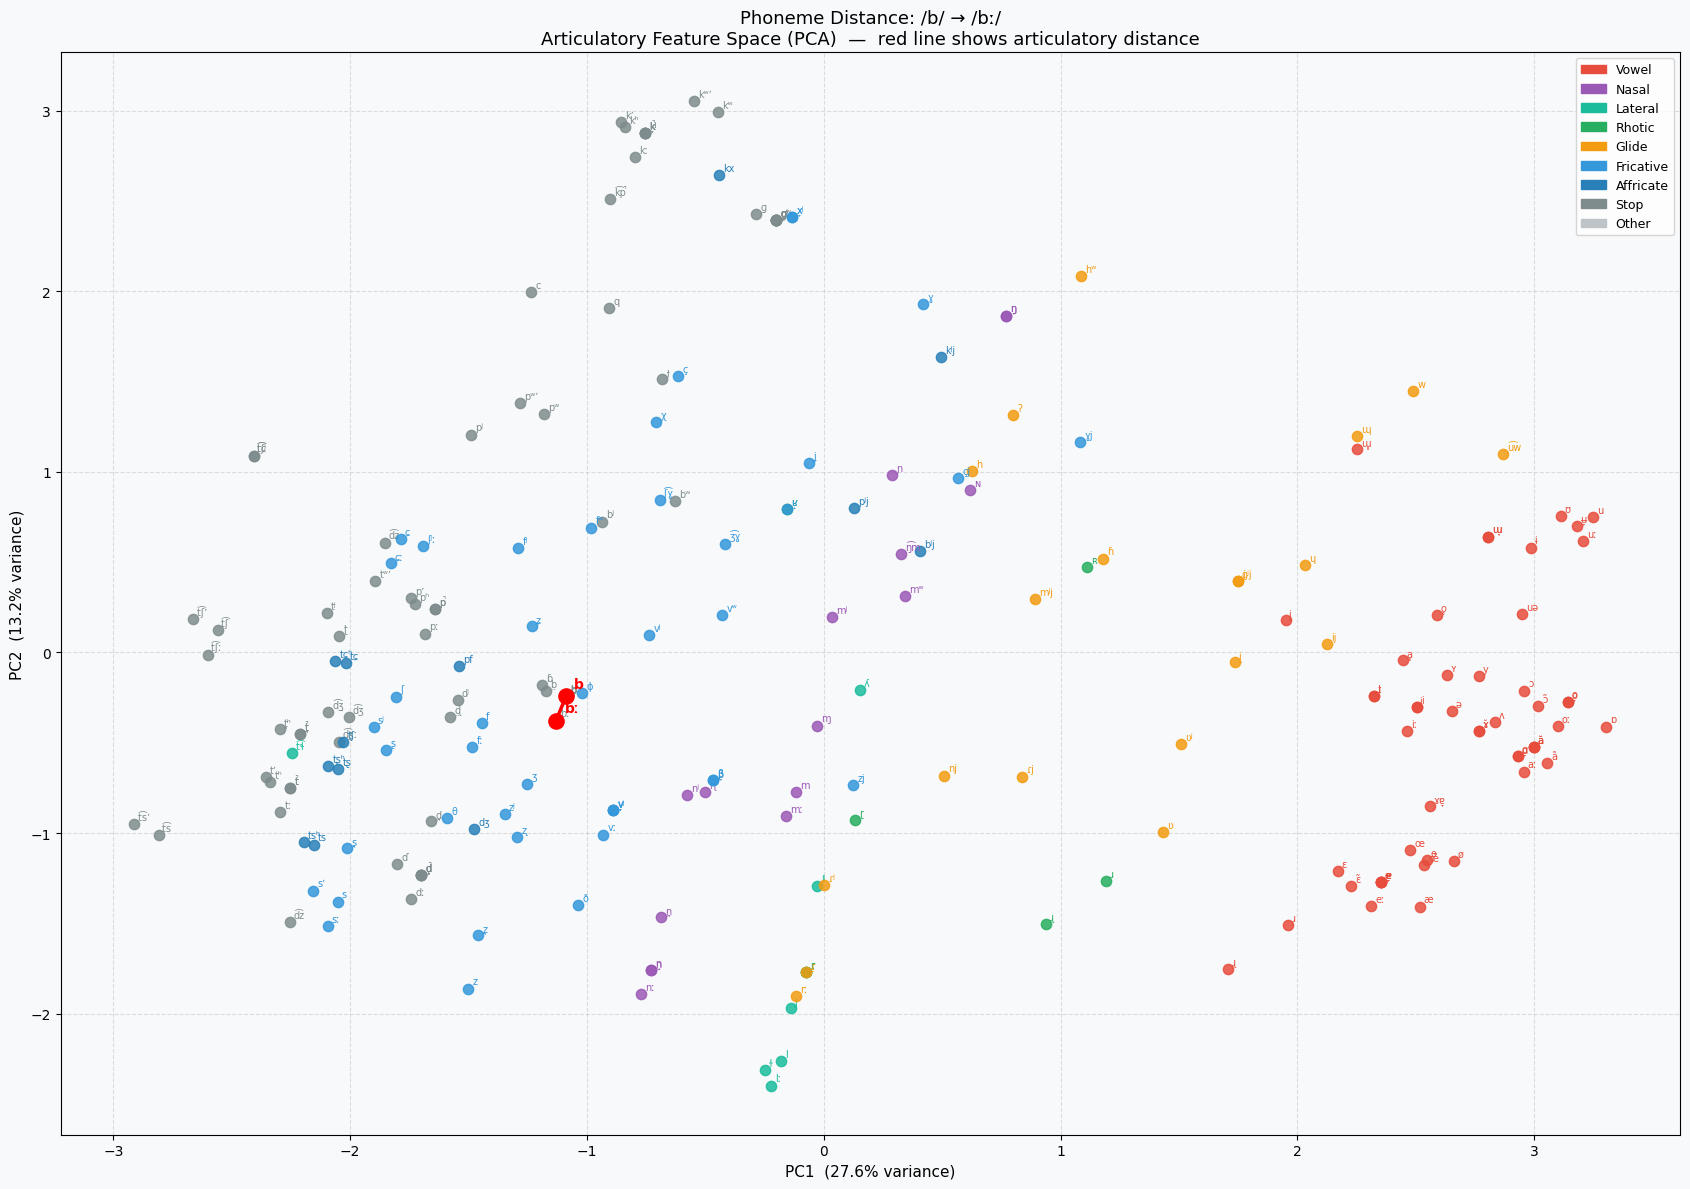

In [ ]:
def DrawPhonemeConnection(phoneme_a, phoneme_b):
    missing = [p for p in [phoneme_a, phoneme_b] if p not in plot_labels]
    if missing:
        print(f"Phoneme(s) not in inventory: {missing}")
        return

    idx_a, idx_b = plot_labels.index(phoneme_a), plot_labels.index(phoneme_b)
    xa, ya = coords[idx_a]
    xb, yb = coords[idx_b]

    fig, ax = plt.subplots(figsize=(17, 12))
    ax.set_facecolor("#f8f9fa")
    fig.patch.set_facecolor("#f8f9fa")

    for i, (x, y) in enumerate(coords):
        colour = CLASS_COLOURS.get(classes[i], CLASS_COLOURS["other"])
        ax.scatter(x, y, color=colour, s=55, zorder=3, alpha=0.85)
        ax.annotate(
            plot_labels[i], (x, y),
            fontsize=7, xytext=(3, 3), textcoords="offset points",
            color=colour, fontfamily="DejaVu Sans",
        )

    ax.plot([xa, xb], [ya, yb], color="red", linewidth=2.5, zorder=5)
    ax.scatter([xa, xb], [ya, yb], color="red", s=120, zorder=6)
    for label, x, y in [(phoneme_a, xa, ya), (phoneme_b, xb, yb)]:
        ax.annotate(
            label, (x, y),
            fontsize=10, fontweight="bold", color="red",
            xytext=(6, 6), textcoords="offset points",
        )

    ax.set_xlabel(f"PC1  ({var[0]*100:.1f}% variance)", fontsize=11)
    ax.set_ylabel(f"PC2  ({var[1]*100:.1f}% variance)", fontsize=11)
    ax.set_title(
        f"Phoneme Distance: /{phoneme_a}/ → /{phoneme_b}/\n"
        f"Articulatory Feature Space (PCA)  —  red line shows articulatory distance",
        fontsize=13,
    )
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(
        handles=[mpatches.Patch(color=c, label=cls.capitalize()) for cls, c in CLASS_COLOURS.items()],
        loc="upper right", fontsize=9, framealpha=0.8,
    )

    plt.tight_layout()
    plt.show()


DrawPhonemeConnection("b", "bː")
